
# Weather Dataset Analysis Project

## Contents
1. Data Loading
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. 10+ Visualizations
5. Feature Engineering
6. Machine Learning Forecasting
7. Model Evaluation
8. Conclusions

Dataset: `popular_cities_weather.csv`


In [1]:

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/rosemeenshaikh/india-weather-dataset-2020-2025/popular_cities_weather.csv')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (7056, 9)


,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
0,2020-01-01 00:00:00,24.9,19.2,29.9,0.0,NaN,1013.4,13800.0,Mumbai
1,2020-02-01 00:00:00,27.3,21.0,32.6,0.0,NaN,1012.7,11220.0,Mumbai
2,2020-03-01 00:00:00,27.7,22.6,31.9,0.0,NaN,1011.2,12900.0,Mumbai
3,2020-04-01 00:00:00,30.2,26.4,33.9,0.0,NaN,1009.6,14220.0,Mumbai
4,2020-05-01 00:00:00,31.1,28.6,34.0,0.0,NaN,1007.3,15960.0,Mumbai


In [2]:

# Basic information
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    7056 non-null   object 
 1   tavg    6517 non-null   float64
 2   tmin    6452 non-null   float64
 3   tmax    6431 non-null   float64
 4   prcp    6126 non-null   float64
 5   wspd    0 non-null      float64
 6   pres    6434 non-null   float64
 7   tsun    2405 non-null   float64
 8   city    7056 non-null   object 
dtypes: float64(7), object(2)
memory usage: 496.3+ KB
None

Missing Values:
date       0
tavg     539
tmin     604
tmax     625
prcp     930
wspd    7056
pres     622
tsun    4651
city       0
dtype: int64

Duplicate Rows: 144



# Data Cleaning & Preprocessing


In [3]:

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Remove duplicate rows
df = df.drop_duplicates()

# Drop completely empty column
df = df.drop(columns=['wspd'])

# Fill missing values with median
numeric_cols = ['tavg', 'tmin', 'tmax', 'prcp', 'pres', 'tsun']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Extract date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Encode city column
encoder = LabelEncoder()
df['city_encoded'] = encoder.fit_transform(df['city'])

print(df.isnull().sum())

df.head()


date            0
tavg            0
tmin            0
tmax            0
prcp            0
pres            0
tsun            0
city            0
year            0
month           0
day             0
city_encoded    0
dtype: int64


,date,tavg,tmin,tmax,prcp,pres,tsun,city,year,month,day,city_encoded
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,13800.0,Mumbai,2020,1,1,62
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,11220.0,Mumbai,2020,2,1,62
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,12900.0,Mumbai,2020,3,1,62
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,14220.0,Mumbai,2020,4,1,62
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,15960.0,Mumbai,2020,5,1,62



# Exploratory Data Analysis (EDA)


In [4]:

# Statistical Summary
df.describe()


,date,tavg,tmin,tmax,prcp,pres,tsun,year,month,day,city_encoded
count,6912,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.000000,6912.0,6912.000000
mean,2022-12-16 06:40:00,25.947396,20.948076,31.619690,108.583492,1008.890668,10686.067708,2022.500000,6.500000,1.0,47.500000
min,2020-01-01 00:00:00,0.600000,-4.500000,5.700000,0.000000,994.800000,1020.000000,2020.000000,1.000000,1.0,0.000000
25%,2021-06-23 12:00:00,23.700000,17.900000,29.500000,5.600000,1004.800000,10740.000000,2021.000000,3.750000,1.0,23.750000
50%,2022-12-16 12:00:00,27.100000,22.500000,32.000000,45.000000,1009.200000,10740.000000,2022.500000,6.500000,1.0,47.500000
75%,2024-06-08 12:00:00,29.300000,25.100000,34.400000,143.025000,1013.000000,10740.000000,2024.000000,9.250000,1.0,71.250000
max,2025-12-01 00:00:00,36.600000,31.000000,44.000000,1768.900000,1025.900000,21360.000000,2025.000000,12.000000,1.0,95.000000
std,NaN,5.047428,5.516682,4.818012,170.876635,5.085411,2280.407816,1.707949,3.452302,0.0,27.713314


## Visualization: Average Temperature Distribution

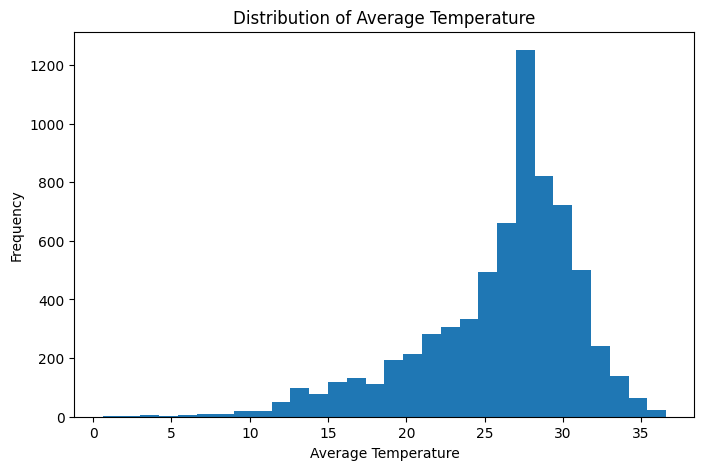

In [5]:

plt.figure(figsize=(8,5))
plt.hist(df['tavg'], bins=30)
plt.title('Distribution of Average Temperature')
plt.xlabel('Average Temperature')
plt.ylabel('Frequency')
plt.show()


## Visualization: Minimum Temperature Distribution

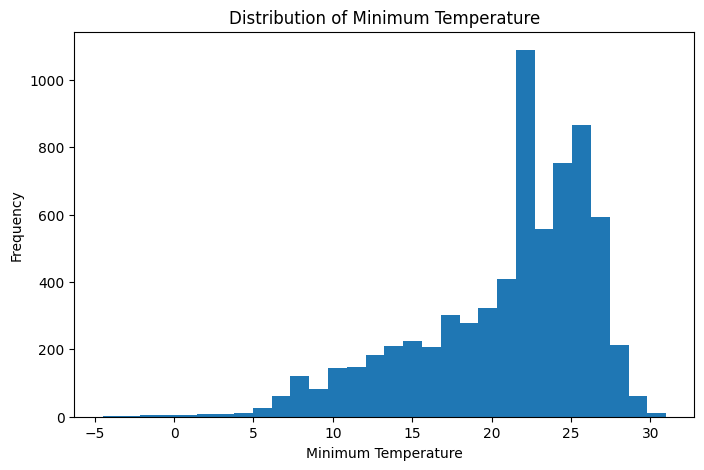

In [6]:

plt.figure(figsize=(8,5))
plt.hist(df['tmin'], bins=30)
plt.title('Distribution of Minimum Temperature')
plt.xlabel('Minimum Temperature')
plt.ylabel('Frequency')
plt.show()


## Visualization: Maximum Temperature Distribution

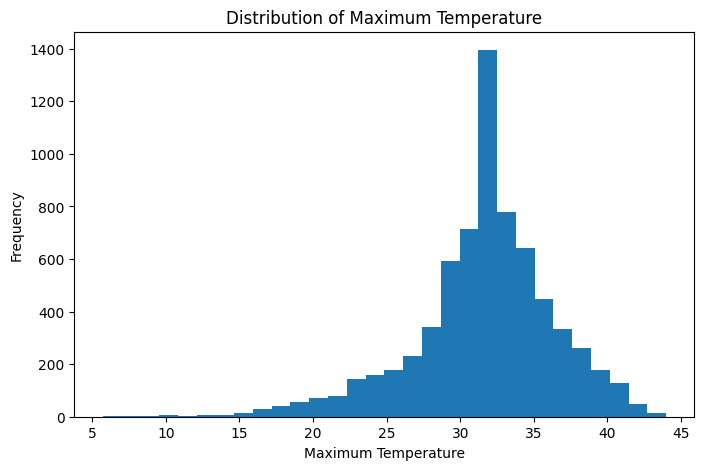

In [7]:

plt.figure(figsize=(8,5))
plt.hist(df['tmax'], bins=30)
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Frequency')
plt.show()


## Visualization: Rainfall Distribution

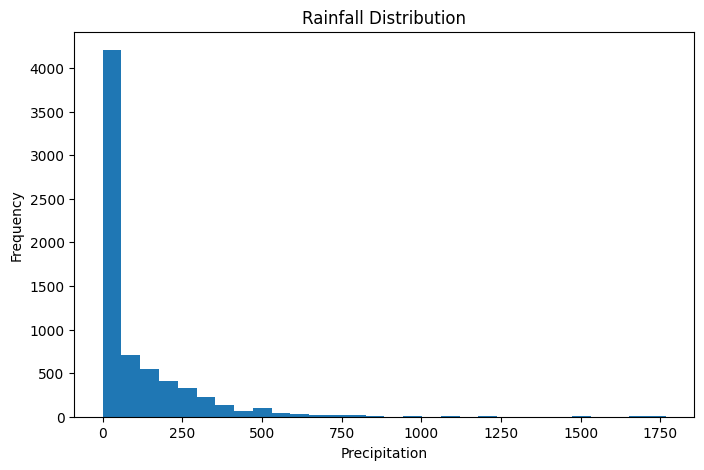

In [8]:

plt.figure(figsize=(8,5))
plt.hist(df['prcp'], bins=30)
plt.title('Rainfall Distribution')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.show()


## Visualization: Pressure Distribution

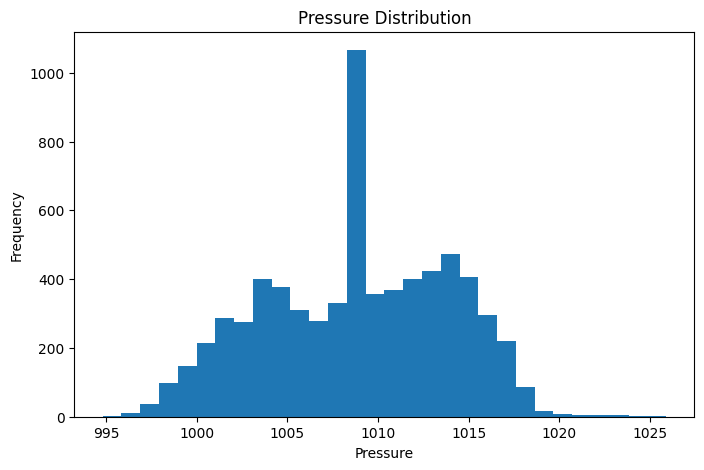

In [9]:

plt.figure(figsize=(8,5))
plt.hist(df['pres'], bins=30)
plt.title('Pressure Distribution')
plt.xlabel('Pressure')
plt.ylabel('Frequency')
plt.show()


## Visualization: Top Cities by Average Temperature

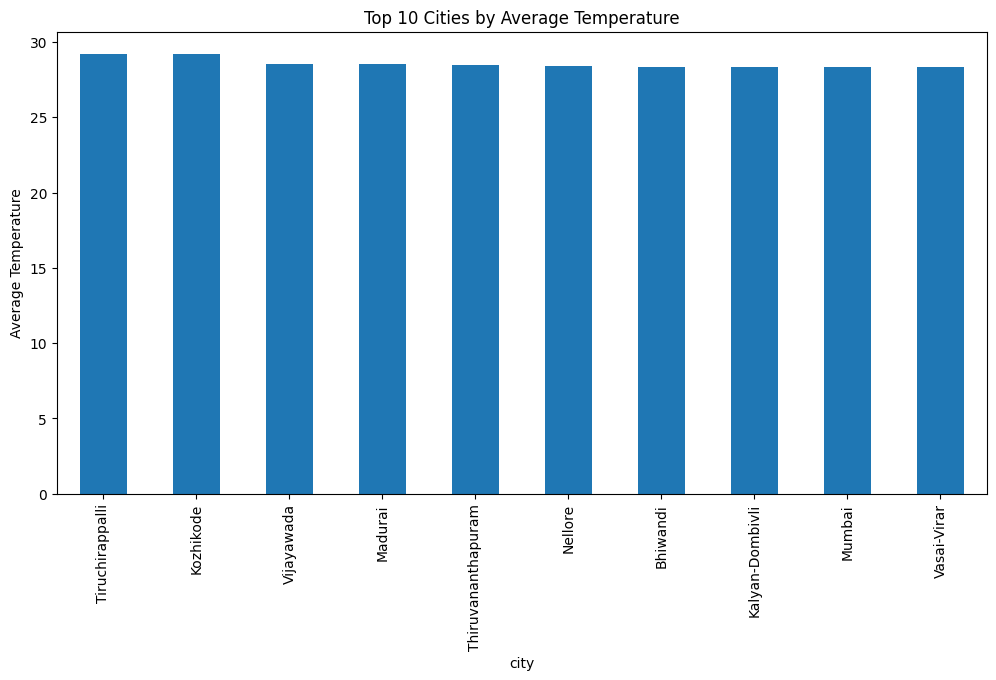

In [10]:

city_temp = df.groupby('city')['tavg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_temp.plot(kind='bar')
plt.title('Top 10 Cities by Average Temperature')
plt.ylabel('Average Temperature')
plt.show()


## Visualization: Monthly Average Temperature Trend

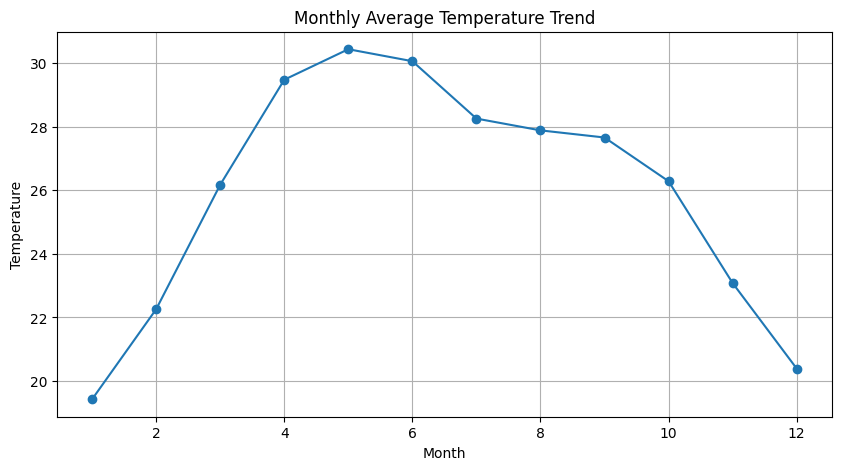

In [11]:

monthly_temp = df.groupby('month')['tavg'].mean()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker='o')
plt.title('Monthly Average Temperature Trend')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()


## Visualization: Monthly Rainfall Trend

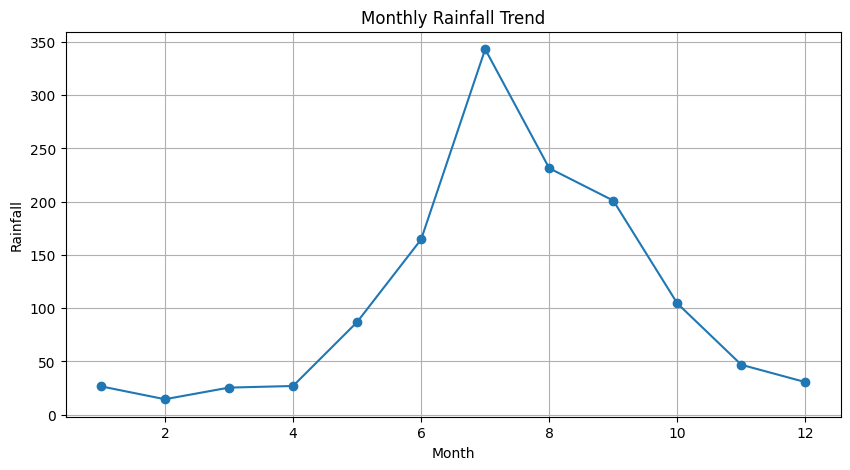

In [12]:

monthly_rain = df.groupby('month')['prcp'].mean()

plt.figure(figsize=(10,5))
monthly_rain.plot(marker='o')
plt.title('Monthly Rainfall Trend')
plt.xlabel('Month')
plt.ylabel('Rainfall')
plt.grid(True)
plt.show()


## Visualization: Yearly Temperature Trend

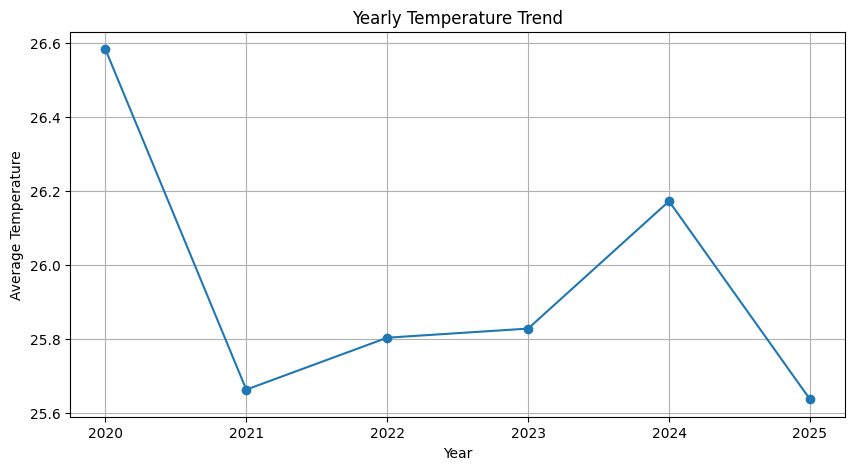

In [13]:

yearly_temp = df.groupby('year')['tavg'].mean()

plt.figure(figsize=(10,5))
yearly_temp.plot(marker='o')
plt.title('Yearly Temperature Trend')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.grid(True)
plt.show()


## Visualization: Temperature vs Pressure Scatter Plot

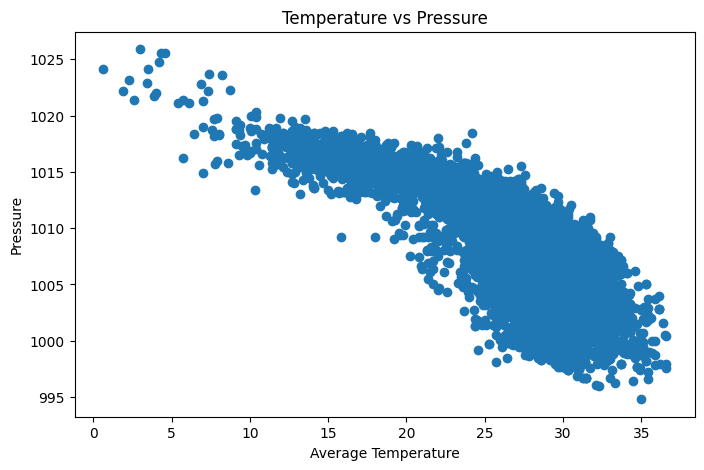

In [14]:

plt.figure(figsize=(8,5))
plt.scatter(df['tavg'], df['pres'])
plt.title('Temperature vs Pressure')
plt.xlabel('Average Temperature')
plt.ylabel('Pressure')
plt.show()


## Visualization: Temperature Correlation Heatmap

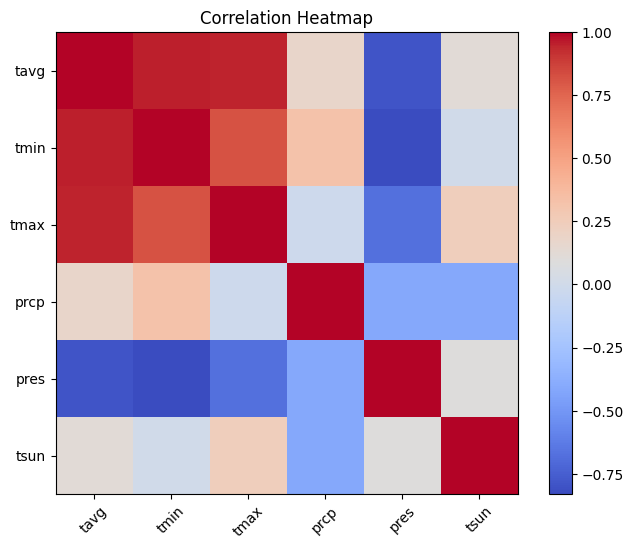

In [15]:

corr = df[['tavg','tmin','tmax','prcp','pres','tsun']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')
plt.show()



# Feature Engineering


In [16]:

# Features and target
features = ['tmin', 'tmax', 'prcp', 'pres', 'tsun', 'year', 'month', 'city_encoded']
target = 'tavg'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (5529, 8)
Testing Shape: (1383, 8)



# Machine Learning Forecasting
Using Random Forest Regressor to forecast average temperature.


In [17]:

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 0.2691388286334074
RMSE: 0.4992722100180543
R2 Score: 0.9896875408087734


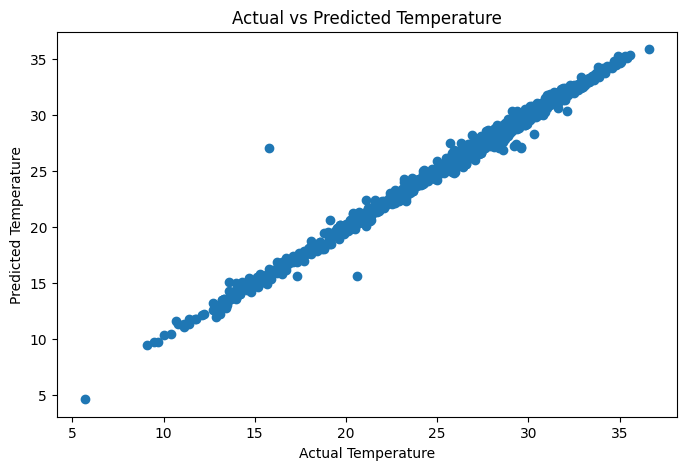

In [18]:

# Actual vs Predicted Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Temperature')

plt.show()


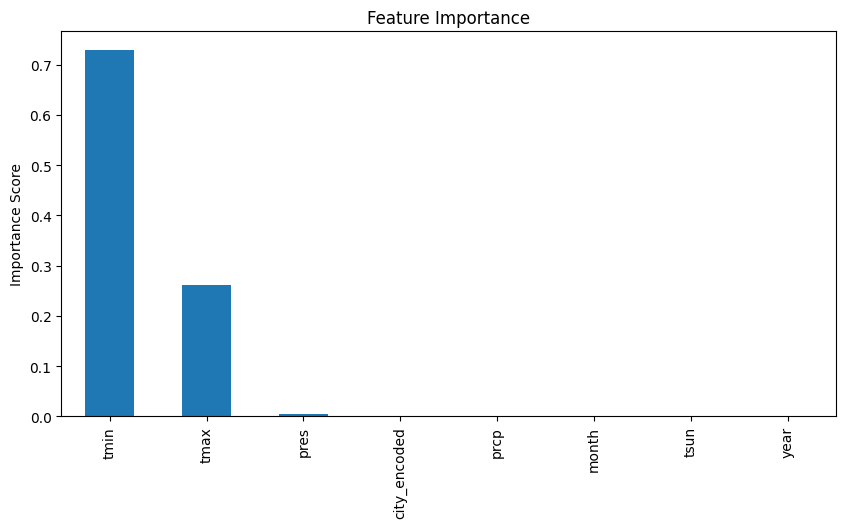

In [19]:

# Feature Importance
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind='bar')

plt.title('Feature Importance')
plt.ylabel('Importance Score')

plt.show()



# Forecast Example


In [20]:

# Sample prediction

sample = X_test.iloc[:5]

predictions = model.predict(sample)

results = sample.copy()
results['Predicted_Temperature'] = predictions

results


,tmin,tmax,prcp,pres,tsun,year,month,city_encoded,Predicted_Temperature
2202,27.2,35.3,208.6,1000.6,10740.0,2023,7,91,30.759
994,20.0,30.1,0.8,1013.5,10740.0,2024,11,69,24.691
6478,13.6,26.9,5.1,1014.8,10740.0,2025,11,30,19.594
6173,21.3,26.8,262.0,1008.1,10740.0,2024,6,10,23.539
4458,26.1,34.5,259.0,997.4,6720.0,2025,7,67,30.120



# Conclusions

## Key Findings
- Dataset contained missing values and one completely empty column (`wspd`).
- Missing values were handled using median imputation.
- Seasonal weather patterns were observed across months.
- Temperature trends vary significantly between cities.
- Random Forest model performed well for temperature forecasting.

## Future Improvements
- Add advanced time-series forecasting models (ARIMA, LSTM, Prophet).
- Use larger datasets with hourly weather records.
- Deploy model as a web app/dashboard.


In [21]:

import plotly.express as px

# Approximate coordinates for Indian cities
city_coords = {
    'Mumbai': (19.0760, 72.8777),
    'Delhi': (28.7041, 77.1025),
    'Bengaluru': (12.9716, 77.5946),
    'Chennai': (13.0827, 80.2707),
    'Kolkata': (22.5726, 88.3639),
    'Hyderabad': (17.3850, 78.4867),
    'Pune': (18.5204, 73.8567),
    'Ahmedabad': (23.0225, 72.5714),
    'Jaipur': (26.9124, 75.7873),
    'Lucknow': (26.8467, 80.9462),
    'Surat': (21.1702, 72.8311),
    'Kanpur': (26.4499, 80.3319),
    'Nagpur': (21.1458, 79.0882),
    'Indore': (22.7196, 75.8577),
    'Bhopal': (23.2599, 77.4126),
    'Patna': (25.5941, 85.1376),
    'Visakhapatnam': (17.6868, 83.2185),
    'Vadodara': (22.3072, 73.1812),
    'Ludhiana': (30.9010, 75.8573),
    'Agra': (27.1767, 78.0081)
}

# Create average city temperature dataframe
city_temp = df.groupby('city')['tavg'].mean().reset_index()

# Add coordinates
city_temp['lat'] = city_temp['city'].map(lambda x: city_coords.get(x, (None, None))[0])
city_temp['lon'] = city_temp['city'].map(lambda x: city_coords.get(x, (None, None))[1])

# Remove rows without coordinates
city_temp = city_temp.dropna()

city_temp.head()

,city,tavg,lat,lon
0,Agra,25.176389,27.1767,78.0081
1,Ahmedabad,28.250000,23.0225,72.5714
11,Bengaluru,24.015278,12.9716,77.5946
15,Bhopal,25.265278,23.2599,77.4126
19,Chennai,28.322222,13.0827,80.2707


In [22]:
# Heatmap Style Visualization

fig = px.density_map(
    city_temp,
    lat='lat',
    lon='lon',
    z='tavg',
    radius=25,
    center=dict(lat=22, lon=78),
    zoom=3,
    map_style='open-street-map',
    title='Indian Temperature Heatmap'
)

fig.show()

In [23]:
# Check Tamil Nadu cities available in dataset

tn_cities = df[df['city'].str.contains(
    'Chennai|Coimbatore|Madurai|Salem|Erode|Vellore|Tirunelveli|Thoothukudi|Trichy|Tiruchirappalli',
    case=False,
    na=False
)]

print(tn_cities['city'].unique())

['Chennai' 'Coimbatore' 'Madurai' 'Tiruchirappalli' 'Salem' 'Tirunelveli']


In [24]:
# Coordinates for Tamil Nadu cities present in dataset

coords = {
    'Chennai': [13.0827, 80.2707],
    'Coimbatore': [11.0168, 76.9558],
    'Madurai': [9.9252, 78.1198],
    'Salem': [11.6643, 78.1460],
    'Erode': [11.3410, 77.7172],
    'Vellore': [12.9165, 79.1325],
    'Tirunelveli': [8.7139, 77.7567],
    'Thoothukudi': [8.7642, 78.1348],
    'Tiruchirappalli': [10.7905, 78.7047]
}

In [25]:
# Filter Tamil Nadu cities from dataset

tn_df = df[df['city'].isin(coords.keys())]

# Average temperature by city

tn_avg = tn_df.groupby('city')['tavg'].mean().reset_index()

# Add coordinates

tn_avg['lat'] = tn_avg['city'].apply(lambda x: coords[x][0])
tn_avg['lon'] = tn_avg['city'].apply(lambda x: coords[x][1])

tn_avg

,city,tavg,lat,lon
0,Chennai,28.322222,13.0827,80.2707
1,Coimbatore,26.900000,11.0168,76.9558
2,Madurai,28.515278,9.9252,78.1198
3,Salem,27.294444,11.6643,78.1460
4,Tiruchirappalli,29.225000,10.7905,78.7047
5,Tirunelveli,28.063889,8.7139,77.7567


In [26]:
# Tamil Nadu temperature heatmap

fig = px.density_mapbox(
    tn_avg,
    lat='lat',
    lon='lon',
    z='tavg',
    radius=35,
    zoom=6,
    center=dict(lat=11.1271, lon=78.6569),
    mapbox_style='open-street-map',
    hover_name='city',
    title='Tamil Nadu Temperature Heatmap'
)

fig.show()